# Deteksi Kesehatan Ternak

## Pendahuluan
Pada notebook ini, kita akan membangun model prediksi untuk mendeteksi kesehatan ternak menggunakan metode **Support Vector Machine (SVM)**. Model ini bertujuan untuk membantu peternak mendeteksi tanda-tanda penyakit pada ternak mereka lebih dini, berdasarkan data kesehatan ternak seperti suhu tubuh, pola makan, dan perilaku.

## Import Library yang Dibutuhkan
Kita akan menggunakan beberapa library Python untuk melakukan analisis dan membangun model SVM.

In [1]:

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score


## Langkah 1: Memuat Dataset
Kita akan memuat dataset kesehatan ternak yang telah dibuat sebelumnya.

In [4]:
# Load the dataset
dummy_ternak_df = pd.read_excel('3_deteksi_kesehatan_ternak.xlsx')
dummy_ternak_df

,Date,Location,Body Temperature (C),Feed Intake (kg),Activity Level (hrs/day),Breathing Rate (breaths/min),Heart Rate (bpm),Health
0,2025-01-18,Farm 5,38.625311,2.961348,4.127917,26,114,Normal
1,2025-01-09,Farm 5,38.133861,2.955176,7.810465,28,61,Heat Stress
2,2025-02-07,Farm 5,39.364740,4.010598,11.607708,10,71,Cold Stress
3,2025-02-15,Farm 1,38.439696,6.980579,10.697643,14,85,Normal
4,2025-01-14,Farm 2,38.669166,4.655944,3.354693,28,60,Cold Stress
...,...,...,...,...,...,...,...,...
295,2025-01-28,Farm 5,38.184524,5.880146,5.969271,14,110,Normal
296,2025-01-28,Farm 2,38.927701,3.836754,8.194220,20,108,Injury
297,2025-02-22,Farm 3,36.943023,4.969742,5.525982,17,61,Injury
298,2025-01-03,Farm 2,37.777429,7.935856,3.666397,25,113,Illness


## Langkah 2: Preprocessing Data
Kita akan melakukan encoding pada kolom kategori, seperti 'Location'.

<Figure size 1000x600 with 0 Axes>

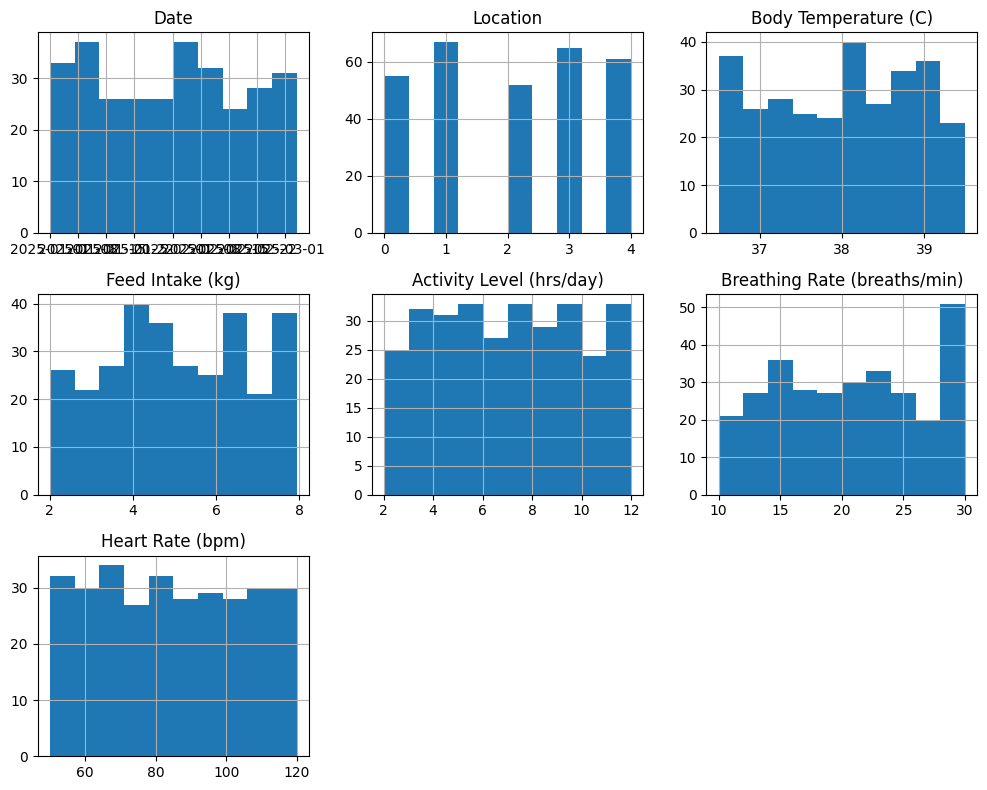

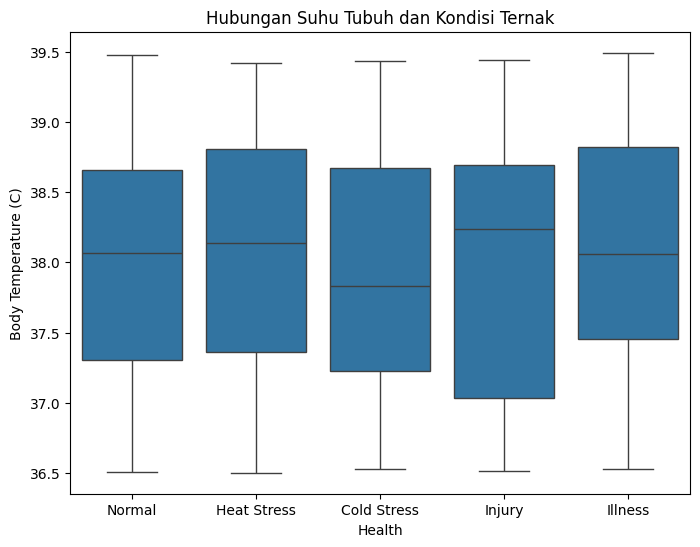

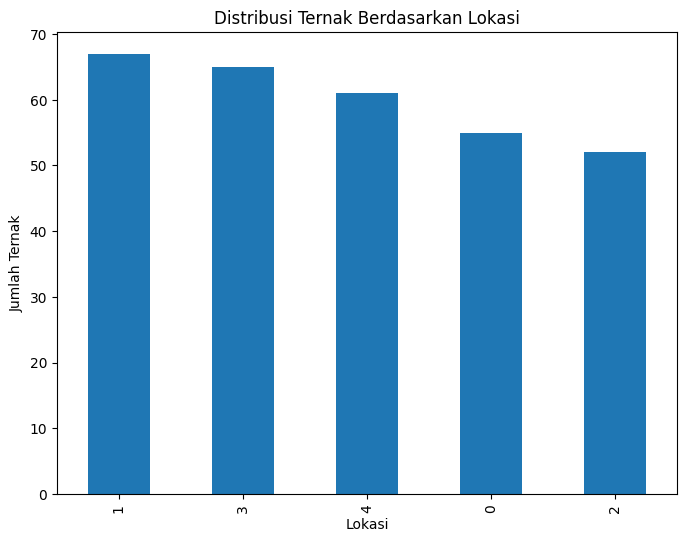

In [15]:
# prompt: buatkan code untuk memvisualisasikan dummy_ternak_df

import matplotlib.pyplot as plt
import seaborn as sns  # Import seaborn for boxplot

# Visualisasi data dummy_ternak_df
plt.figure(figsize=(10, 6))  # Atur ukuran gambar
dummy_ternak_df.hist(bins=10, figsize=(10, 8))  # Membuat histogram untuk setiap kolom numerik
plt.tight_layout()
plt.show()

# Contoh visualisasi lain: Box plot
plt.figure(figsize=(8, 6))
# Use seaborn's boxplot function
sns.boxplot(x='Health', y='Body Temperature (C)', data=dummy_ternak_df)
plt.xlabel('Health')  # Updated x-axis label
plt.ylabel('Body Temperature (C)')  # Updated y-axis label
plt.title('Hubungan Suhu Tubuh dan Kondisi Ternak')
plt.show()

# Contoh visualisasi lain: Bar plot (jika ada kolom kategorikal)
if 'Location' in dummy_ternak_df.columns:  # Cek keberadaan kolom Location
    location_counts = dummy_ternak_df['Location'].value_counts()
    plt.figure(figsize=(8, 6))
    location_counts.plot(kind='bar')
    plt.xlabel('Lokasi')
    plt.ylabel('Jumlah Ternak')
    plt.title('Distribusi Ternak Berdasarkan Lokasi')
    plt.show()

In [5]:
# Encoding categorical variables
encoder = LabelEncoder()

# Assuming categorical columns are: 'Lokasi', 'Pola Makan', 'Aktivitas'
for column in ['Location']:
    dummy_ternak_df[column] = encoder.fit_transform(dummy_ternak_df[column])

# Splitting the data into features and target variable
X = dummy_ternak_df.drop(columns=["Health", "Date"])
y = dummy_ternak_df["Health"]

## Langkah 3: Normalisasi Data
Kita akan melakukan normalisasi pada data fitur untuk memastikan nilai-nilai berada dalam rentang yang seragam.

In [6]:

# Normalizing the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


## Langkah 4: Membagi Data Train dan Test
Kita akan membagi dataset menjadi data pelatihan (train) dan data pengujian (test).

In [7]:

# Splitting the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


## Langkah 5: Melatih Model
Sekarang kita akan membangun dan melatih model **SVM** untuk mendeteksi kesehatan ternak.

In [8]:

# Building the Support Vector Machine model
svm_model_ternak = SVC(kernel='linear', random_state=42)

# Training the model
svm_model_ternak.fit(X_train, y_train)


SVC(kernel='linear', random_state=42)

## Langkah 6: Evaluasi Model
Setelah model dilatih, kita akan mengevaluasi kinerjanya dengan menggunakan data uji.

In [9]:

# Making predictions on the test set
y_pred_ternak_svm = svm_model_ternak.predict(X_test)

# Evaluating the model
print("Accuracy:", accuracy_score(y_test, y_pred_ternak_svm))
print(classification_report(y_test, y_pred_ternak_svm))


Accuracy: 0.23333333333333334
              precision    recall  f1-score   support

 Cold Stress       0.00      0.00      0.00        16
 Heat Stress       0.23      1.00      0.38        14
     Illness       0.00      0.00      0.00         8
      Injury       0.00      0.00      0.00        13
      Normal       0.00      0.00      0.00         9

    accuracy                           0.23        60
   macro avg       0.05      0.20      0.08        60
weighted avg       0.05      0.23      0.09        60



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Langkah 7: Prediksi
Kita akan menggunakan model untuk melakukan prediksi pada data baru.

In [11]:

# Example prediction (predicting on the first row of X_test)
example_prediction_ternak_svm = svm_model_ternak.predict(X_test[:1])
print("Predicted Health Event:", example_prediction_ternak_svm)


Predicted Health Event: ['Heat Stress']



## Keterangan Penting

Notebook ini menggunakan data dummy untuk mendeteksi kesehatan ternak berdasarkan beberapa fitur, seperti suhu tubuh, pola makan, dan aktivitas ternak. Agar model ini dapat menghasilkan prediksi yang lebih akurat dan relevan, **kustomisasi lebih lanjut diperlukan**. Beberapa hal yang perlu dipertimbangkan antara lain:

1. **Penyempurnaan Dataset**: Data yang digunakan adalah data dummy yang bersifat acak. Untuk hasil yang lebih baik, dataset harus diisi dengan data kesehatan ternak yang lebih realistis dan sesuai dengan kondisi lokal yang relevan.
   
2. **Penyesuaian Fitur**: Beberapa fitur, seperti suhu tubuh, pola makan, atau tingkat aktivitas, perlu penyesuaian atau penambahan fitur lain yang lebih berdampak pada deteksi penyakit pada ternak.

3. **Parameter Model**: Untuk hasil prediksi yang lebih optimal, Anda dapat menyesuaikan parameter model SVM atau mencoba model lain yang lebih sesuai dengan karakteristik data.

4. **Validasi Model**: Melakukan validasi dengan data nyata dan cross-validation untuk mengevaluasi kinerja model.

Dengan penyesuaian yang tepat, model ini dapat memberikan deteksi kesehatan ternak yang lebih akurat dan bermanfaat untuk menjaga kesehatan ternak dan meningkatkan produktivitas peternakan.
